# Deep Equilibrium Models and SILVA

The DEQ baseline in this notebook solves

$$
z^\star=\tanh(W_z z^\star+W_x x+b).
$$

SILVA keeps the same fixed-point idea but splits the transition into named
branches:

$$
z^\star
=\sigma\{S_\theta(x)+H_\theta(z^\star)+L_\theta(z^\star)+G_\theta(z^\star)\}.
$$

The names are operational:

- $S_\theta$: stimulus from data.
- $H_\theta$: optional learned self-interaction inside the transition.
- $L_\theta$: local interaction, for example graph messages or dynamic kNN.
- $G_\theta$: global context, for example mean field or bounded attention.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [3](https://jseluis.github.io/silva-networks/paper/references/#ref-3), [4](https://jseluis.github.io/silva-networks/paper/references/#ref-4). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(7)
np.random.seed(7)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## DEQ MLP Baseline

This mirrors the compact DEQ experiment: solve one equilibrium state and train a
linear readout on top.

In [3]:
from silva_networks import silva_fixed_point_classifier

x = torch.randn(40, 6, device=device)
y = (x[:, :3].sum(dim=1) > x[:, 3:].sum(dim=1)).long()
deq_model = silva_fixed_point_classifier(
    in_features=6,
    state_dim=16,
    num_classes=2,
    config=SolverConfig(solver="anderson", max_iter=8, alpha=0.6, history=4),
).to(device)

out = deq_model(x, return_result=True)
loss = torch.nn.functional.cross_entropy(out.output, y)
loss.backward()
out.output.shape, out.solver_result.solver, out.solver_result.residual

(torch.Size([40, 2]), 'anderson', 0.03303724527359009)

## SILVA Graph Variant

Now convert the same rows into graph entities. A k-nearest-neighbor graph
defines local messages, while a mean-field or attention term supplies global
context.

In [4]:
from silva_networks import SILVAGraphNetwork, make_knn_edge_index

edge_index = make_knn_edge_index(x.detach(), k=4, metric="cosine", undirected=True, device=device)
silva = SILVAGraphNetwork(
    in_dim=6,
    hidden_dims=[16, 16],
    out_dim=2,
    task="node",
    local=["graph", "gat"],
    global_term=["mean", "topk"],
    self_term=["none", "linear"],
    local_kwargs=[{}, {"heads": 4, "add_self_loops": True}],
    global_kwargs=[{}, {"k": 6}],
    config=[
        SolverConfig(solver="picard", max_iter=6, alpha=0.55),
        SolverConfig(solver="anderson", max_iter=6, alpha=0.45, history=3),
    ],
).to(device)

result = silva(x, edge_index=edge_index, return_results=True)
silva_loss = torch.nn.functional.cross_entropy(result.output, y)
silva_loss.backward()
result.output.shape, result.state.shape, [r.solver for r in result.solver_results]

(torch.Size([40, 2]), torch.Size([40, 16]), ['picard', 'anderson'])

## Residual Diagnostics

Both models are controlled by `SolverConfig`. The solver choice, damping,
history, tolerance, and iteration budget can be changed per layer.

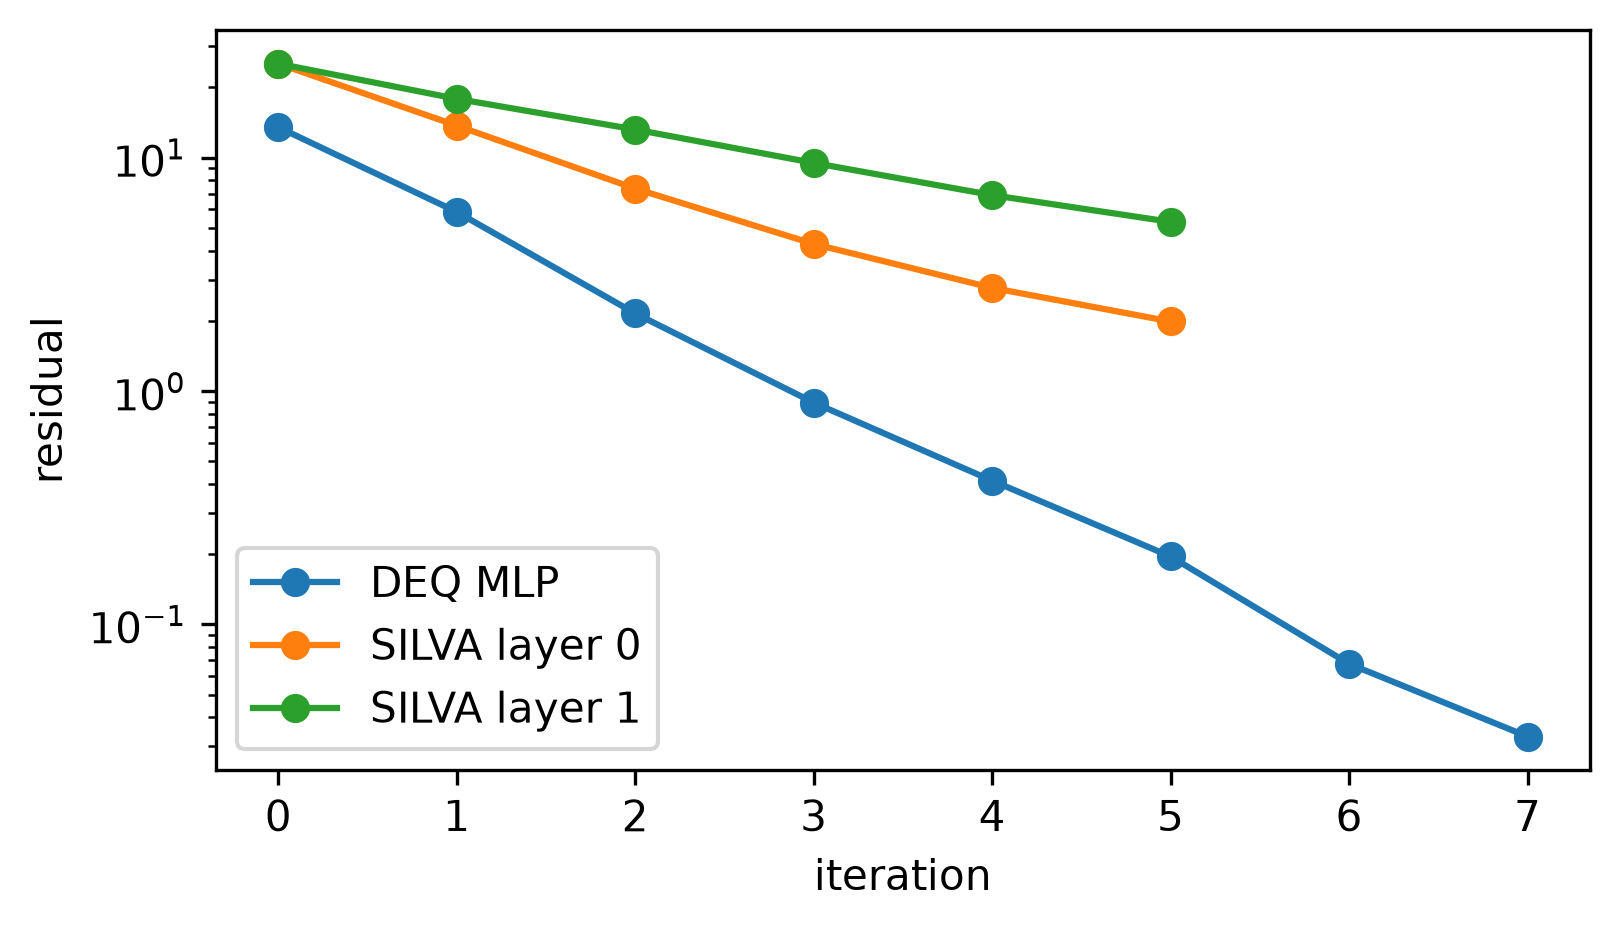

In [5]:
plt.figure(figsize=(5.5, 3.2))
plt.plot(out.solver_result.residuals, marker="o", label="DEQ MLP")
for index, solver_result in enumerate(result.solver_results):
    plt.plot(solver_result.residuals, marker="o", label=f"SILVA layer {index}")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("residual")
plt.legend()
plt.tight_layout()

## Citation and Sources

If this package or notebook is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.1.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA methodology, cite the SILVA Networks
paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background sources:

- Deep Implicit Layers tutorial: https://implicit-layers-tutorial.org/
- LocusLab DEQ repository: https://github.com/locuslab/deq
- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models: https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization: https://arxiv.org/abs/2106.14342

The notebook is adapted to the `silva_networks` public API. It links to the
sources above and keep the examples package-native.

## From 04 Deq And Silva to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [6]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [7]:
notebook_reproduction_record = {
    "notebook": '04_deq_and_silva.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '04_deq_and_silva.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Where to Go Next

| Question | Page |
| --- | --- |
| How does the general engine connect to SILVA? | [DEQ Engine and Optical Flow](https://jseluis.github.io/silva-networks/learn/deq-engine-and-flow/) |
| How is a named-branch SILVA layer assembled? | [SILVA From Scratch](https://jseluis.github.io/silva-networks/learn/silva-from-scratch/) |
| Which structured-state engine objects are public? | [DEQ Engine API](https://jseluis.github.io/silva-networks/api/deq-engine/) |
